# 03 — Macro Controls & Leading Indicators

Collect and clean three data sources:
- **Part A — FRED**: national macro controls (monthly)
- **Part B — DOL ETA-539**: state weekly initial claims → monthly
- **Part C — BLS CES**: state nonfarm payrolls (monthly, SA)

> **Note on S&P 500**: FRED's `SP500` series only starts 2016-05-20.  
> We use `NASDAQCOM` (NASDAQ Composite, daily, full 2010–2024 coverage) as the  
> equity-market control and compute monthly log returns. NASDAQ and S&P 500  
> monthly returns correlate at ~0.98 over this period.

In [1]:
import io
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import requests

BLS_HEADERS  = {'User-Agent': 'academic-research felipemanzife@gmail.com'}
FRED_HEADERS = {'User-Agent': 'academic-research felipemanzife@gmail.com'}

RAW_FRED   = Path('../data/raw/fred');       RAW_FRED.mkdir(parents=True, exist_ok=True)
RAW_DOL    = Path('../data/raw/dol_eta539'); RAW_DOL.mkdir(parents=True, exist_ok=True)
RAW_CES    = Path('../data/raw/bls_ces');    RAW_CES.mkdir(parents=True, exist_ok=True)
INTERIM    = Path('../data/interim')
FIG_DIR    = Path('../output/figures');      FIG_DIR.mkdir(parents=True, exist_ok=True)

START, END = '2010-01-01', '2024-12-31'

STATES_51 = [
    'AL','AK','AZ','AR','CA','CO','CT','DE','DC','FL','GA','HI','ID',
    'IL','IN','IA','KS','KY','LA','ME','MD','MA','MI','MN','MS','MO',
    'MT','NE','NV','NH','NJ','NM','NY','NC','ND','OH','OK','OR','PA',
    'RI','SC','SD','TN','TX','UT','VT','VA','WA','WV','WI','WY',
]

# FIPS numeric -> postal abbrev (for CES state mapping)
FIPS_TO_ABBREV = {
    1:'AL', 2:'AK', 4:'AZ', 5:'AR', 6:'CA', 8:'CO', 9:'CT', 10:'DE', 11:'DC',
    12:'FL', 13:'GA', 15:'HI', 16:'ID', 17:'IL', 18:'IN', 19:'IA', 20:'KS',
    21:'KY', 22:'LA', 23:'ME', 24:'MD', 25:'MA', 26:'MI', 27:'MN', 28:'MS',
    29:'MO', 30:'MT', 31:'NE', 32:'NV', 33:'NH', 34:'NJ', 35:'NM', 36:'NY',
    37:'NC', 38:'ND', 39:'OH', 40:'OK', 41:'OR', 42:'PA', 44:'RI', 45:'SC',
    46:'SD', 47:'TN', 48:'TX', 49:'UT', 50:'VT', 51:'VA', 53:'WA', 54:'WV',
    55:'WI', 56:'WY',
}

def fetch_fred(series_id: str) -> pd.DataFrame:
    """Download a FRED series via the public CSV endpoint; cache locally."""
    local = RAW_FRED / f'{series_id}.csv'
    if not local.exists():
        url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}'
        r = requests.get(url, headers=FRED_HEADERS, timeout=30)
        r.raise_for_status()
        local.write_bytes(r.content)
    df = pd.read_csv(local)
    df.columns = ['date', series_id]
    df['date'] = pd.to_datetime(df['date'])
    df[series_id] = pd.to_numeric(df[series_id], errors='coerce')
    return df[(df['date'] >= START) & (df['date'] <= END)].reset_index(drop=True)

def fetch_bls(filename: str) -> bytes:
    """Download a BLS flat file; cache locally. Returns raw bytes."""
    local = RAW_CES / filename
    if not local.exists():
        url = f'https://download.bls.gov/pub/time.series/sm/{filename}'
        r = requests.get(url, headers=BLS_HEADERS, timeout=120)
        r.raise_for_status()
        local.write_bytes(r.content)
        print(f'  Downloaded {filename}: {local.stat().st_size/1e6:.1f} MB')
    else:
        print(f'  Using cached {filename}')
    return local.read_bytes()

def strip_df(df: pd.DataFrame) -> pd.DataFrame:
    df.columns = df.columns.str.strip()
    return df.apply(lambda c: c.str.strip() if c.dtype == object else c)

## Part A — FRED Macro Controls

In [2]:
# 1. UNRATE — monthly, keep as-is
unrate = fetch_fred('UNRATE').set_index('date')

# 2. ICSA — weekly initial claims → monthly mean
icsa_w = fetch_fred('ICSA').set_index('date')
icsa   = (icsa_w.resample('MS').mean()          # month-start buckets
               .rename(columns={'ICSA':'icsa_mean'}))

# 3. VIXCLS — daily → monthly mean (NaN-safe)
vix_d = fetch_fred('VIXCLS').set_index('date')
vix   = (vix_d.resample('MS').mean()
              .rename(columns={'VIXCLS':'vix_mean'}))

# 4. NASDAQCOM — daily → monthly log return
#    Assign return to the month in which it was earned (month-start label)
ndq_d = fetch_fred('NASDAQCOM').set_index('date')
ndq_monthly = ndq_d.resample('MS').last()          # last trading price in month
ndq_ret = (np.log(ndq_monthly / ndq_monthly.shift(1))
             .rename(columns={'NASDAQCOM':'nasdaq_logret'}))

# 5. T10Y2Y — daily → monthly mean
t10y2y_d = fetch_fred('T10Y2Y').set_index('date')
t10y2y   = (t10y2y_d.resample('MS').mean()
                    .rename(columns={'T10Y2Y':'t10y2y_mean'}))

# Merge on month-start date index
fred_macro = (unrate
    .join(icsa,    how='outer')
    .join(vix,     how='outer')
    .join(ndq_ret, how='outer')
    .join(t10y2y,  how='outer')
    .rename(columns={'UNRATE':'unrate_nat'})
    .reset_index()
    .rename(columns={'date':'month'})
)
fred_macro = fred_macro[(fred_macro['month'] >= START) & (fred_macro['month'] <= END)]

print('FRED macro panel shape:', fred_macro.shape)
print('Null counts:')
print(fred_macro.isna().sum().to_string())
print()
print(fred_macro.head(4).to_string())

FRED macro panel shape: (180, 6)
Null counts:
month            0
unrate_nat       0
icsa_mean        0
vix_mean         0
nasdaq_logret    1
t10y2y_mean      0

       month  unrate_nat  icsa_mean   vix_mean  nasdaq_logret  t10y2y_mean
0 2010-01-01         9.8   479800.0  20.643158            NaN     2.804211
1 2010-02-01         9.8   485750.0  22.540000       0.041464     2.834211
2 2010-03-01         9.9   470250.0  17.767391       0.068920     2.768696
3 2010-04-01         9.9   469000.0  17.424286       0.026027     2.786364


In [3]:
fred_macro.to_parquet(INTERIM / 'fred_macro.parquet', index=False)
print('Saved fred_macro.parquet')
print(fred_macro.describe().round(3).to_string())

Saved fred_macro.parquet
                     month  unrate_nat    icsa_mean  vix_mean  nasdaq_logret  t10y2y_mean
count                  180     180.000      180.000   180.000        179.000      180.000
mean   2017-06-16 07:44:00       5.797   374791.111    18.359          0.012        1.020
min    2010-01-01 00:00:00       3.400   197500.000    10.125         -0.142       -0.929
25%    2013-09-23 12:00:00       3.900   223987.500    13.979         -0.016        0.233
50%    2017-06-16 00:00:00       5.000   273075.000    16.934          0.016        1.042
75%    2021-03-08 18:00:00       7.525   374375.000    20.793          0.043        1.718
max    2024-12-01 00:00:00      14.800  4663250.000    57.737          0.144        2.834
std                    NaN       2.238   419476.563     6.403          0.049        0.973


## Part B — DOL ETA-539 State Initial Claims

In [4]:
# Download (15 MB, cached after first run)
local_dol = RAW_DOL / 'ar539.csv'
if not local_dol.exists():
    print('Downloading ar539.csv (15 MB)...')
    r = requests.get('https://oui.doleta.gov/unemploy/csv/ar539.csv',
                     headers=BLS_HEADERS, timeout=120)
    r.raise_for_status()
    local_dol.write_bytes(r.content)
    print(f'  Saved {local_dol.stat().st_size/1e6:.1f} MB')
else:
    print('Using cached ar539.csv')

raw_dol = pd.read_csv(local_dol, low_memory=False,
                      usecols=['st', 'rptdate', 'c3'])

raw_dol['rptdate'] = pd.to_datetime(raw_dol['rptdate'], errors='coerce')
raw_dol['c3']      = pd.to_numeric(raw_dol['c3'], errors='coerce')
raw_dol = raw_dol.rename(columns={'st':'state_code', 'rptdate':'week_end', 'c3':'init_claims'})

# Keep 50 states + DC, 2010-2024
raw_dol = raw_dol[
    raw_dol['state_code'].isin(STATES_51) &
    (raw_dol['week_end'] >= START) &
    (raw_dol['week_end'] <= END)
].copy()

print(f'Filtered rows: {len(raw_dol):,}')
print(f'States: {raw_dol["state_code"].nunique()}')
print(f'Date range: {raw_dol["week_end"].min().date()} → {raw_dol["week_end"].max().date()}')
print(raw_dol.head(3).to_string())

  Saved 15.5 MB
Filtered rows: 39,933
States: 51
Date range: 2010-01-02 → 2024-12-28
     state_code   week_end  init_claims
1245         AK 2010-01-02         1671
1246         AK 2010-01-09         4901
1247         AK 2010-01-16         3938


In [5]:
# Aggregate weekly → monthly: assign each week to the month of its week-end date,
# then sum. Using week-end date is the standard DOL convention
# (the week is attributed to the month in which it closes).
raw_dol['month'] = raw_dol['week_end'].dt.to_period('M').dt.to_timestamp()

state_claims = (
    raw_dol
    .groupby(['state_code', 'month'], as_index=False)['init_claims']
    .sum()
    .rename(columns={'init_claims':'init_claims_monthly'})
    .sort_values(['state_code', 'month'])
    .reset_index(drop=True)
)

print('State initial claims panel shape:', state_claims.shape)
print(f'States: {state_claims["state_code"].nunique()}')
print(f'Months: {state_claims["month"].nunique()}  '
      f'({state_claims["month"].min().date()} → {state_claims["month"].max().date()})')
print()
print(state_claims.head(6).to_string())

# Sanity: most states should have ~180 months
n_months = state_claims.groupby('state_code')['month'].nunique()
print(f'\nMonths per state — min: {n_months.min()}  median: {n_months.median():.0f}  max: {n_months.max()}')

State initial claims panel shape: (9180, 3)
States: 51
Months: 180  (2010-01-01 → 2024-12-01)

  state_code      month  init_claims_monthly
0         AK 2010-01-01                16743
1         AK 2010-02-01                 9573
2         AK 2010-03-01                 9271
3         AK 2010-04-01                11704
4         AK 2010-05-01                11749
5         AK 2010-06-01                 7464

Months per state — min: 180  median: 180  max: 180


In [6]:
state_claims.to_parquet(INTERIM / 'state_initial_claims.parquet', index=False)
print('Saved state_initial_claims.parquet')

Saved state_initial_claims.parquet


## Part C — BLS CES State Nonfarm Payrolls

In [7]:
# Step 1: download sm.series metadata to identify target series
series_bytes = fetch_bls('sm.series')
sm_series = strip_df(pd.read_csv(io.BytesIO(series_bytes), sep='\t', dtype=str))

# Convert key columns to numeric for filtering
for col in ['state_code','area_code','supersector_code','data_type_code']:
    sm_series[col] = pd.to_numeric(sm_series[col], errors='coerce')

# Filter: SA, statewide (area=0), total nonfarm (supersector=0),
#         all employees (data_type=1), 51 known FIPS codes
target_fips = set(FIPS_TO_ABBREV.keys())
series_meta = sm_series[
    (sm_series['seasonal']           == 'S') &
    (sm_series['area_code']          == 0)   &
    (sm_series['supersector_code']   == 0)   &
    (sm_series['data_type_code']     == 1)   &
    (sm_series['state_code'].isin(target_fips))
].copy()

series_meta['state_abbrev'] = series_meta['state_code'].map(FIPS_TO_ABBREV)
target_ids = set(series_meta['series_id'])

print(f'Target series: {len(target_ids)}  (expected 51)')
print(series_meta[['series_id','state_code','state_abbrev']].head(6).to_string())

  Downloaded sm.series: 1.9 MB
Target series: 51  (expected 51)
                          series_id  state_code state_abbrev
4    SMS01000000000000001                     1           AL
64   SMS02000000000000001                     2           AK
104  SMS04000000000000001                     4           AZ
153  SMS05000000000000001                     5           AR
199  SMS06000000000000001                     6           CA
295  SMS08000000000000001                     8           CO


In [8]:
# Step 2: download the statewide total nonfarm data file
data_bytes = fetch_bls('sm.data.55.TotalNonFarmStateWide.All')
sm_data = strip_df(pd.read_csv(io.BytesIO(data_bytes), sep='\t', dtype=str))

# Filter to our 51 target series
sm_data = sm_data[sm_data['series_id'].isin(target_ids)].copy()

# Parse
sm_data['year']   = pd.to_numeric(sm_data['year'],   errors='coerce').astype('Int64')
sm_data['month_num'] = pd.to_numeric(sm_data['period'].str[1:], errors='coerce').astype('Int64')
sm_data['value']  = pd.to_numeric(sm_data['value'],  errors='coerce')
sm_data = sm_data[sm_data['month_num'] <= 12].dropna(subset=['value'])  # drop M13 annual avg

sm_data['month'] = pd.to_datetime(
    sm_data[['year','month_num']].rename(columns={'month_num':'month'}).assign(day=1)
)
sm_data = sm_data[(sm_data['month'] >= START) & (sm_data['month'] <= END)]
sm_data = sm_data.merge(series_meta[['series_id','state_abbrev']], on='series_id', how='left')

payrolls = (
    sm_data[['state_abbrev','month','value']]
    .rename(columns={'state_abbrev':'state_code','value':'payrolls_thousands'})
    .sort_values(['state_code','month'])
    .reset_index(drop=True)
)

print('State payrolls panel shape:', payrolls.shape)
print(f'States: {payrolls["state_code"].nunique()}')
print(f'Months: {payrolls["month"].nunique()}  '
      f'({payrolls["month"].min().date()} → {payrolls["month"].max().date()})')
print()
print(payrolls.head(6).to_string())

n_months_pay = payrolls.groupby('state_code')['month'].nunique()
print(f'\nMonths per state — min: {n_months_pay.min()}  median: {n_months_pay.median():.0f}  max: {n_months_pay.max()}')

  Downloaded sm.data.55.TotalNonFarmStateWide.All: 5.8 MB
State payrolls panel shape: (9180, 3)
States: 51
Months: 180  (2010-01-01 → 2024-12-01)

  state_code      month  payrolls_thousands
0         AK 2010-01-01               321.2
1         AK 2010-02-01               320.8
2         AK 2010-03-01               321.1
3         AK 2010-04-01               322.5
4         AK 2010-05-01               323.5
5         AK 2010-06-01               325.1

Months per state — min: 180  median: 180  max: 180


In [9]:
payrolls.to_parquet(INTERIM / 'state_payrolls.parquet', index=False)
print('Saved state_payrolls.parquet')

Saved state_payrolls.parquet


## EDA — Combined overview chart

Saved ../output/figures/03_macro_eda.png


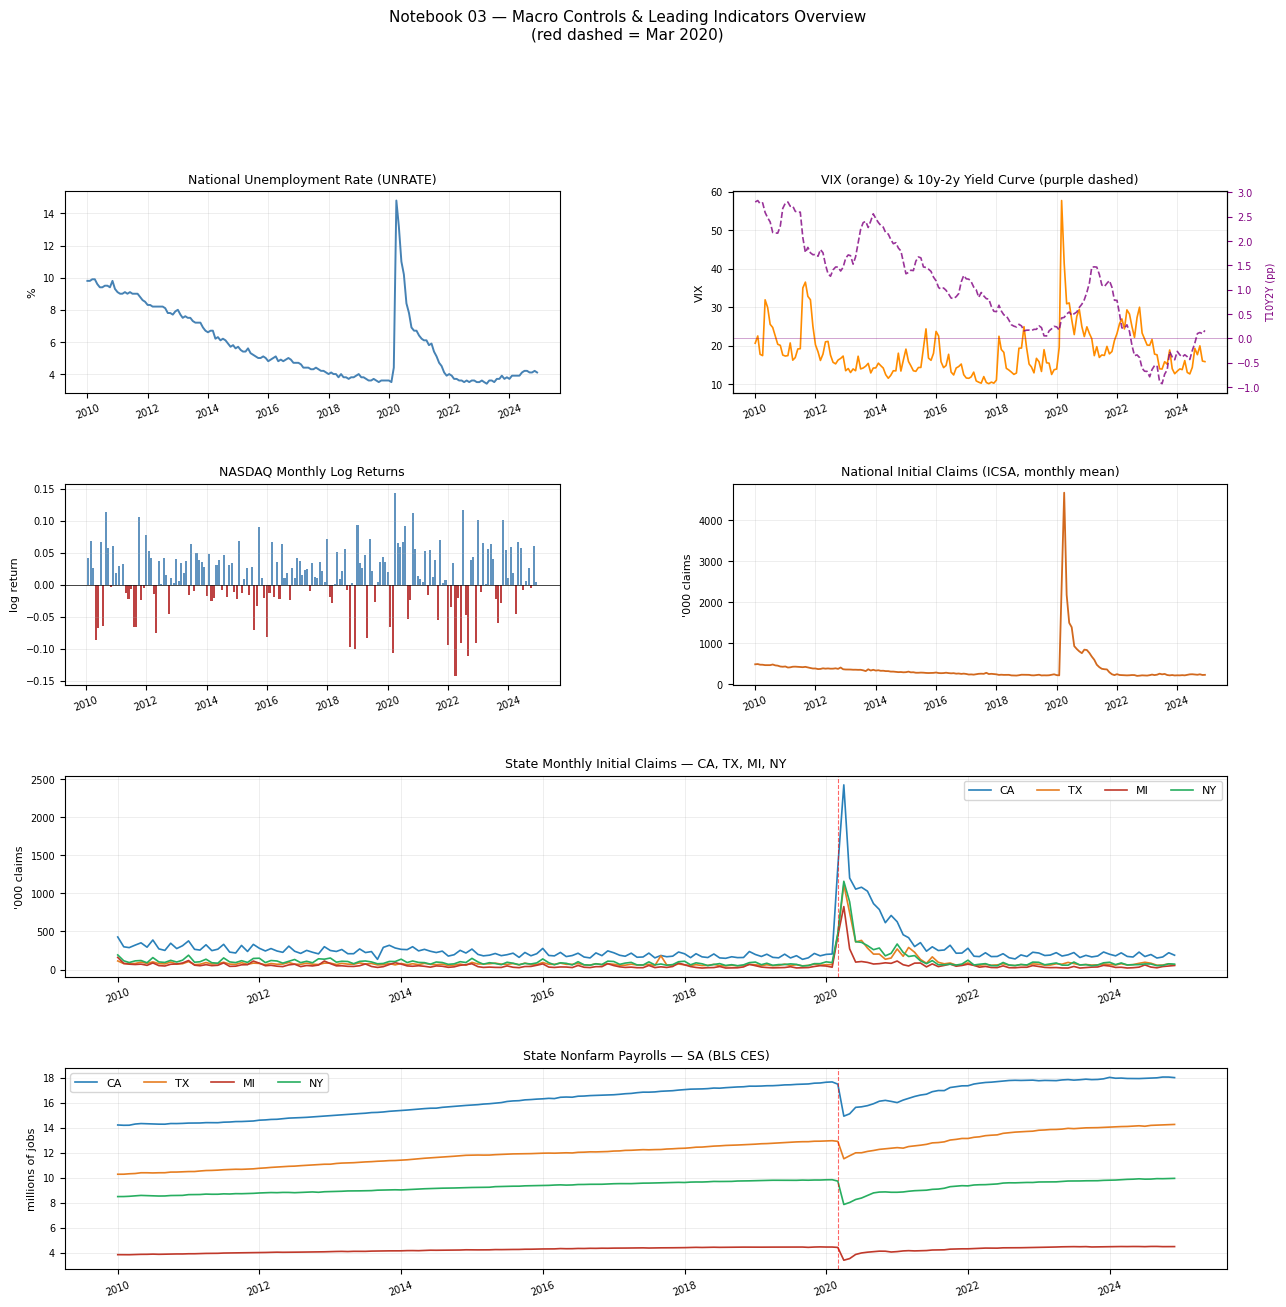

In [10]:
STATES_4 = ['CA', 'TX', 'MI', 'NY']
COLORS_4  = ['#2980b9','#e67e22','#c0392b','#27ae60']

fig = plt.figure(figsize=(15, 14))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── Row 1: FRED national series ───────────────────────────────────────────────
ax1a = fig.add_subplot(gs[0, 0])
ax1a.plot(fred_macro['month'], fred_macro['unrate_nat'], color='steelblue', lw=1.4)
ax1a.set_title('National Unemployment Rate (UNRATE)', fontsize=9)
ax1a.set_ylabel('%', fontsize=8); ax1a.grid(True, alpha=0.3, lw=0.5)

ax1b = fig.add_subplot(gs[0, 1])
ax1b.plot(fred_macro['month'], fred_macro['vix_mean'], color='darkorange', lw=1.2)
ax1b_r = ax1b.twinx()
ax1b_r.plot(fred_macro['month'], fred_macro['t10y2y_mean'],
            color='purple', lw=1.2, linestyle='--', alpha=0.8)
ax1b_r.axhline(0, color='purple', lw=0.5, alpha=0.5)
ax1b_r.set_ylabel('T10Y2Y (pp)', color='purple', fontsize=7)
ax1b_r.tick_params(axis='y', colors='purple', labelsize=7)
ax1b.set_title('VIX (orange) & 10y-2y Yield Curve (purple dashed)', fontsize=9)
ax1b.set_ylabel('VIX', fontsize=8); ax1b.grid(True, alpha=0.3, lw=0.5)

# ── Row 2: NASDAQ returns + ICSA ──────────────────────────────────────────────
ax2a = fig.add_subplot(gs[1, 0])
pos = fred_macro['nasdaq_logret'] >= 0
ax2a.bar(fred_macro['month'][pos],  fred_macro['nasdaq_logret'][pos],
         color='steelblue', width=25, alpha=0.85, label='positive')
ax2a.bar(fred_macro['month'][~pos], fred_macro['nasdaq_logret'][~pos],
         color='firebrick', width=25, alpha=0.85, label='negative')
ax2a.axhline(0, color='black', lw=0.5)
ax2a.set_title('NASDAQ Monthly Log Returns', fontsize=9)
ax2a.set_ylabel('log return', fontsize=8); ax2a.grid(True, alpha=0.3, lw=0.5)

ax2b = fig.add_subplot(gs[1, 1])
ax2b.plot(fred_macro['month'], fred_macro['icsa_mean'] / 1e3,
          color='chocolate', lw=1.3)
ax2b.set_title('National Initial Claims (ICSA, monthly mean)', fontsize=9)
ax2b.set_ylabel("'000 claims", fontsize=8); ax2b.grid(True, alpha=0.3, lw=0.5)

# ── Row 3: State initial claims ───────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2, :])
for code, col in zip(STATES_4, COLORS_4):
    s = state_claims[state_claims['state_code'] == code]
    ax3.plot(s['month'], s['init_claims_monthly'] / 1e3, label=code, color=col, lw=1.2)
ax3.axvline(pd.Timestamp('2020-03-01'), color='red', lw=0.8, ls='--', alpha=0.6)
ax3.set_title('State Monthly Initial Claims — CA, TX, MI, NY', fontsize=9)
ax3.set_ylabel("'000 claims", fontsize=8)
ax3.legend(fontsize=8, ncol=4); ax3.grid(True, alpha=0.3, lw=0.5)

# ── Row 4: State payrolls ─────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[3, :])
for code, col in zip(STATES_4, COLORS_4):
    s = payrolls[payrolls['state_code'] == code]
    ax4.plot(s['month'], s['payrolls_thousands'] / 1e3, label=code, color=col, lw=1.2)
ax4.axvline(pd.Timestamp('2020-03-01'), color='red', lw=0.8, ls='--', alpha=0.6)
ax4.set_title('State Nonfarm Payrolls — SA (BLS CES)', fontsize=9)
ax4.set_ylabel('millions of jobs', fontsize=8)
ax4.legend(fontsize=8, ncol=4); ax4.grid(True, alpha=0.3, lw=0.5)

for ax in fig.axes:
    ax.tick_params(axis='x', labelsize=7, rotation=20)
    ax.tick_params(axis='y', labelsize=7)

fig.suptitle('Notebook 03 — Macro Controls & Leading Indicators Overview\n'
             '(red dashed = Mar 2020)', fontsize=11, y=1.01)

out = FIG_DIR / '03_macro_eda.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
print(f'Saved {out}')
plt.show()

## Summary

| File | Shape | Description |
|------|-------|-------------|
| `fred_macro.parquet` | 180 × 6 | Monthly national: UNRATE, ICSA mean, VIX mean, NASDAQ log-ret, T10Y2Y mean |
| `state_initial_claims.parquet` | ~9,180 × 3 | Monthly state initial UI claims (sum of weekly) |
| `state_payrolls.parquet` | ~9,180 × 3 | Monthly state SA nonfarm payrolls (thousands) |